# Load QM9 Dataset

In [1]:
import os
from pathlib import Path
from torch_geometric.datasets import QM9

DATA_ROOT = Path.cwd().parent / "data" / "QM9"

dataset = QM9(DATA_ROOT)

/home/doterog/repos/uva/research/drifting-experiments/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/doterog/repos/uva/research/drifting-experiments/.venv/lib/python3.11/site-packages/torch_geometric/data/dataset.py:115: UserWarning: The `pre_transform` argument differs from the one used in the pre-processed version of this dataset. If you want to make use of another pre-processing technique, pass `force_reload=True` explicitly to reload the dataset.
  self._process()


# Define MLP, Loss, and Training Loop

- Reminder: norm_diff and node_attr are dead params
- We are missing the normalization factor that is passed with the sum of both GCNs

In [75]:
import torch
from torch import nn
from torch_geometric.nn import MessagePassing

class TypeGCN(MessagePassing):
    propagate_type = {"type_feat": torch.Tensor, "edge_attr": torch.Tensor}

    def __init__(
        self, hidden_nf: int, attention: bool = True, aggr_type: str = "sum"
    ):
        super().__init__(aggr=aggr_type)

        in_message_dim = hidden_nf * 2 + 2
        self.message_mlp = nn.Sequential(
            nn.Linear(in_message_dim, in_message_dim),
            nn.SiLU(),
            nn.Linear(in_message_dim, hidden_nf),
        )

        self.update_mlp = nn.Sequential(
            nn.Linear(hidden_nf * 2, hidden_nf),
            nn.SiLU(),
            nn.Linear(hidden_nf, hidden_nf),
        )

        self.attention = attention
        if self.attention:
            self.att_mlp = nn.Sequential(
                nn.Linear(hidden_nf, 1),
                nn.Sigmoid(),
            )

    def message(
        self,
        type_feat_i: torch.Tensor,
        type_feat_j: torch.Tensor,
        edge_attr: torch.Tensor
    ) -> torch.Tensor:
        input_tensor = torch.cat(
            [type_feat_i, type_feat_j, edge_attr],
            dim=-1,
        )
        out = self.message_mlp(input_tensor)

        if self.attention:
            att_val = self.att_mlp(out)
            return out * att_val

        return out

    def update(self, aggr_out: torch.Tensor, type_feat: torch.Tensor) -> torch.Tensor:
        out = torch.cat([aggr_out, type_feat], dim=-1)
        return type_feat + self.update_mlp(out)

    def forward(
        self, type_feat: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor
    ) -> torch.Tensor:
        return self.propagate(
            edge_index, type_feat=type_feat, edge_attr=edge_attr
        )


class PosGCN(MessagePassing):
    propagate_type = {
        "type_feat": torch.Tensor,
        "scaled_dir_vector": torch.Tensor,
        "edge_attr": torch.Tensor,
    }

    def __init__(
        self,
        hidden_nf: int,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__(aggr=aggr_type)

        in_message_dim = hidden_nf * 2 + 2

        layer = nn.Linear(hidden_nf, 1, bias=False)
        torch.nn.init.xavier_uniform_(layer.weight, gain=0.001)

        self.coord_mlp = nn.Sequential(
            nn.Linear(in_message_dim, hidden_nf),
            nn.SiLU(),
            nn.Linear(hidden_nf, hidden_nf),
            nn.SiLU(),
            layer,
        )

        self.tanh_coord_updates = tanh_coord_updates
        self.coords_range = coords_range

    def message(
        self,
        type_feat_i: torch.Tensor,
        type_feat_j: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> torch.Tensor:
        input_tensor = torch.cat([type_feat_i, type_feat_j, edge_attr], dim=-1)
        weight = self.coord_mlp(input_tensor)
        if self.tanh_coord_updates:
            weight = torch.tanh(weight) * self.coords_range
        return scaled_dir_vector * weight

    def forward(
        self,
        pos: torch.Tensor,
        type_feat: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> torch.Tensor:
        delta = self.propagate(
            edge_index,
            type_feat=type_feat,
            edge_attr=edge_attr,
            scaled_dir_vector=scaled_dir_vector,
        )
        return pos + delta


class EquivariantBlock(nn.Module):
    def __init__(
        self,
        hidden_nf: int,
        n_layers: int = 1,
        attention: bool = True,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__()

        self.type_update = nn.ModuleList(
            [
                TypeGCN(hidden_nf, attention=attention, aggr_type=aggr_type)
                for _ in range(n_layers)
            ]
        )

        self.coord_update = PosGCN(
            hidden_nf,
            tanh_coord_updates=tanh_coord_updates,
            coords_range=coords_range,
            aggr_type=aggr_type,
        )

    def forward(
        self,
        type_feat: torch.Tensor,
        pos: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,
        scaled_dir_vector: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        for type_gcn in self.type_update:
            type_feat = type_gcn(
                type_feat=type_feat,
                edge_index=edge_index,
                edge_attr=edge_attr
            )

        pos = self.coord_update(
            pos=pos,
            type_feat=type_feat,
            edge_index=edge_index,
            edge_attr=edge_attr,
            scaled_dir_vector=scaled_dir_vector,
        )

        return type_feat, pos

def compute_edge_properties(
    pos: torch.Tensor, edge_index: torch.Tensor, norm_constant: float = 1.0
) -> tuple[torch.Tensor, torch.Tensor]:
    src, dst = edge_index
    dist = pos[src] - pos[dst]
    squared_norm = dist.pow(2).sum(dim=-1)
    norm = squared_norm.sqrt()
    scaled_dir_vector = dist / (norm.unsqueeze(-1) + norm_constant)
    return squared_norm, scaled_dir_vector

class EGNN(nn.Module):
    def __init__(
        self,
        num_atom_types: int,
        num_blocks: int = 9,
        hidden_nf: int = 256,
        num_layers_per_block: int = 1,
        attention: bool = True,
        tanh_coord_updates: bool = True,
        coords_range: float = 15.0,
        aggr_type: str = "sum",
    ):
        super().__init__()
        self.type_embedding = nn.Linear(num_atom_types, hidden_nf)
        self.type_embedding_out = nn.Linear(hidden_nf, num_atom_types)
        self.blocks = nn.ModuleList(
            [
                EquivariantBlock(
                    hidden_nf,
                    n_layers=num_layers_per_block,
                    attention=attention,
                    tanh_coord_updates=tanh_coord_updates,
                    coords_range=coords_range,
                    aggr_type=aggr_type,
                )
                for _ in range(num_blocks)
            ]
        )

    def forward(
        self,
        pos_noise: torch.Tensor,
        type_noise: torch.Tensor,
        edge_index: torch.Tensor,
        return_change_in_pos: bool = False,
    ) -> tuple[torch.Tensor, torch.Tensor]:

        gen_feats = self.type_embedding(type_noise)
        gen_pos = pos_noise
        initial_squared_norm, _ = compute_edge_properties(gen_pos, edge_index)

        pos_list = []
        if return_change_in_pos:
            pos_list.append(gen_pos.clone())

        for block in self.blocks:
            squared_norm, scaled_dir_vector = compute_edge_properties(gen_pos, edge_index)
            edge_attr = torch.cat(
                [initial_squared_norm.unsqueeze(-1), squared_norm.unsqueeze(-1)],
                dim=-1,
            )
            gen_feats, gen_pos = block(
                type_feat=gen_feats,
                pos=gen_pos,
                edge_index=edge_index,
                scaled_dir_vector=scaled_dir_vector,
                edge_attr=edge_attr,
            )
            if return_change_in_pos:
                pos_list.append(gen_pos.clone())

        gen_types = self.type_embedding_out(gen_feats)

        if return_change_in_pos:
            return gen_pos, gen_types, pos_list
        return gen_pos, gen_types

In [3]:
def compute_drifting_field(gen_mol, real_mol, sigma = 1.0):
    n_gen = gen_mol.size(0)
    n_real = real_mol.size(0)

    targets = torch.cat([gen_mol, real_mol], dim=0)

    # [N_gen, N_targets, D]
    diffs = targets.unsqueeze(0) - gen_mol.unsqueeze(1)

    # [N_gen, N_targets]
    sq_dists = (diffs * diffs).sum(dim=-1)

    kernel = torch.exp(-sq_dists / (2 * sigma**2))

    kernel_neg, kernel_pos = torch.split(kernel, [n_gen, n_real], dim=1)
    diffs_neg, diffs_pos = torch.split(diffs, [n_gen, n_real], dim=1)

    weighted_neg = kernel_neg.unsqueeze(-1) * diffs_neg
    weighted_pos = kernel_pos.unsqueeze(-1) * diffs_pos

    Z_neg = kernel_neg.sum(dim=1, keepdim=True)
    Z_pos = kernel_pos.sum(dim=1, keepdim=True)

    v_neg = weighted_neg.sum(dim=1) / (Z_neg + 1e-8)
    v_pos = weighted_pos.sum(dim=1) / (Z_pos + 1e-8)
    return v_pos - v_neg

In [4]:

def sample_pos_noise(n_gen_mols: int, num_nodes: int):
    """Sample and center position noise for"""
    pos_noise = torch.randn((n_gen_mols * num_nodes, 3))
    batch_vec = torch.arange(n_gen_mols).repeat_interleave(num_nodes)
    pos_noise = center_positions_per_mol(pos_noise, batch_vec)
    pos_noise = pos_noise / pos_noise.std(dim=0)
    return pos_noise


def sample_type_noise(n_gen_mols: int, num_nodes: int, num_atom_types: int):
    """Sample random noise as embedding for atom types"""
    type_noise = torch.randn((n_gen_mols * num_nodes, num_atom_types))
    return type_noise


def train(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    num_iters: int,
    n_gen_mols: int,
    num_nodes: int,
):
    loss_list = []
    for iter in range(num_iters):
        optimizer.zero_grad()

        # Sample noise once but for multiple molecules
        # as the real molecules
        noise = sample_pos_noise(n_gen_mols, num_nodes)
        noise = noise.view(n_gen_mols, -1)

        # Perform forward pass
        gen_mol = model(noise)

        # Compute loss
        V = compute_drifting_field(gen_mol, real_pos.unsqueeze(0))
        gen_mol_drifted = (gen_mol + V).detach()
        loss = F.mse_loss(gen_mol_drifted, gen_mol)

        # Perform backward pass
        loss.backward()
        optimizer.step()

        # Logging
        loss_list.append(loss.mean().item())
        if (iter + 1) % 500 == 0:
            print(f"Iter {iter}: Loss = {loss.mean().item()}")

    return loss_list, model


# Ops/Geom Aux Fns

In [5]:
from torch_geometric.nn import global_mean_pool

def get_sorted_mols(gen_mols, real_mol):
    dists = torch.cdist(gen_mols, real_mol)
    closest_indices = torch.argsort(dists, dim=0)
    return gen_mols[closest_indices], closest_indices

def center_positions_per_mol(
    pos: torch.Tensor, batch_vec: torch.Tensor = None
) -> torch.Tensor:
    """Zero-center coordinates independently for each graph in a batch."""
    if batch_vec is None:
        return pos - pos.mean(dim=0, keepdim=True)
    com = global_mean_pool(pos, batch_vec)  # [G, 3]
    return pos - com[batch_vec]

# Viz Aux Fns

In [181]:
import matplotlib.pyplot as plt
import torch

def visualize_both_molecules(gen_pos: torch.Tensor, real_pos: torch.Tensor):
    gen_pos = gen_pos.view(-1, 3).detach().cpu().numpy()
    real_pos = real_pos.view(-1, 3).detach().cpu().numpy()

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(gen_pos[:, 0],  gen_pos[:, 1],  gen_pos[:, 2],  color='red',  label='Generated', alpha=0.8)
    ax.scatter(real_pos[:, 0], real_pos[:, 1], real_pos[:, 2], color='blue', label='Real',      alpha=0.8)

    ax.set_title('Generated vs Real Molecule')
    ax.legend()
    plt.show()

def _apply_limits(ax, x_lim, y_lim, z_lim):
    ax.set_autoscale_on(False)
    ax.set_xlim3d(*x_lim)
    ax.set_ylim3d(*y_lim)
    ax.set_zlim3d(*z_lim)


def _plot_molecule(ax, pos, types, title='', limits=None):
    """Scatter-plots a single molecule onto an existing 3-D axis."""
    if limits is not None:
        ax.set_autoscale_on(False)          # lock before any scatter call
        ax.set_xlim3d(*limits[0])
        ax.set_ylim3d(*limits[1])
        ax.set_zlim3d(*limits[2])

    pos_np = pos.view(-1, 3).detach().cpu().numpy()
    types_r = torch.round(types, decimals=0)

    for atom_type in torch.unique(types_r):
        mask = (types_r == atom_type).cpu().numpy()
        ax.scatter(pos_np[mask, 0], pos_np[mask, 1], pos_np[mask, 2],
                   label=f'Type {atom_type.item()}')

    ax.set_title(title)
    ax.legend(fontsize=7)


def visualize_progression_with_real(
    pos_list: list[torch.Tensor],
    gen_types: torch.Tensor,
    real_pos: torch.Tensor,
    real_types: torch.Tensor,
    step_indices: list[int] | None = None,
    max_steps: int = 5
):
    if step_indices is None:
        total = len(pos_list)
        step_indices = [int(i * (total - 1) / (max_steps - 1)) for i in range(max_steps)]

    # --- Compute consistent limits from ALL positions (trajectory + real) ---
    all_pos = torch.cat(
        [p.view(-1, 3) for p in pos_list] + [real_pos.view(-1, 3)]
    ).detach().cpu().numpy()

    padding = 0.5
    limits = (
        (all_pos[:, 0].min() - padding, all_pos[:, 0].max() + padding),
        (all_pos[:, 1].min() - padding, all_pos[:, 1].max() + padding),
        (all_pos[:, 2].min() - padding, all_pos[:, 2].max() + padding),
    )

    def _enforce_limits(ax):
        ax.set_autoscale_on(False)
        ax.set_xlim3d(*limits[0])
        ax.set_ylim3d(*limits[1])
        ax.set_zlim3d(*limits[2])

        ax.set_xticks([int(t) for t in range(int(limits[0][0]), int(limits[0][1]) + 1)])
        ax.set_yticks([int(t) for t in range(int(limits[1][0]), int(limits[1][1]) + 1)])
        ax.set_zticks([int(t) for t in range(int(limits[2][0]), int(limits[2][1]) + 1)])

    n_cols = len(step_indices) + 2
    fig = plt.figure(figsize=(4 * n_cols, 4))

    # --- Generated snapshots ---
    for plot_idx, step_idx in enumerate(step_indices):
        ax = fig.add_subplot(1, n_cols, plot_idx + 1, projection='3d')
        _plot_molecule(ax, pos_list[step_idx], gen_types, title=f'Step {step_idx}')
        _enforce_limits(ax)

    # --- Real molecule with atom types ---
    ax_real = fig.add_subplot(1, n_cols, n_cols - 1, projection='3d')
    _plot_molecule(ax_real, real_pos, real_types, title='Real Molecule')
    _enforce_limits(ax_real)

    # --- Overlap: final generated vs real ---
    ax_overlap = fig.add_subplot(1, n_cols, n_cols, projection='3d')
    final_pos = pos_list[-1].view(-1, 3).detach().cpu().numpy()
    real_pos_np = real_pos.view(-1, 3).detach().cpu().numpy()
    ax_overlap.scatter(final_pos[:, 0],   final_pos[:, 1],   final_pos[:, 2],   color='red',  label='Generated', alpha=0.8)
    ax_overlap.scatter(real_pos_np[:, 0], real_pos_np[:, 1], real_pos_np[:, 2], color='blue', label='Real',      alpha=0.8)
    ax_overlap.set_title('Final vs Real')
    ax_overlap.legend(fontsize=7)
    _enforce_limits(ax_overlap)

    plt.tight_layout()
    plt.show()


def visualize_both_molecules_with_atom_types(
    gen_pos, gen_types, real_pos, real_types
):
    fig = plt.figure(figsize=(12, 6))
    _plot_molecule(fig.add_subplot(121, projection='3d'), gen_pos,  gen_types,  'Generated Molecule')
    _plot_molecule(fig.add_subplot(122, projection='3d'), real_pos, real_types, 'Real Molecule')
    plt.show()


def plot_loss(loss_list):
    plt.plot(loss_list)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

# Sample Single Noise ONCE

Number of nodes: 5
Center of mass of real molecule positions: tensor([0., 0., 0.], device='cuda:0')
Std of real molecule positions: tensor([1.0000, 1.0000, 1.0000], device='cuda:0')
Real molecule atom types shape: torch.Size([5, 5])
Combined real molecule shape: torch.Size([5, 8])
Combined noise shape: torch.Size([5, 8])

Iter 99: Loss = 0.2580552101135254
Iter 199: Loss = 0.24650458991527557
Iter 299: Loss = 0.21851606667041779
Iter 399: Loss = 0.22491168975830078
Iter 499: Loss = 0.20844359695911407
Iter 599: Loss = 0.18779659271240234
Iter 699: Loss = 0.1599746197462082
Iter 799: Loss = 0.11753731220960617
Iter 899: Loss = 0.06767550855875015
Iter 999: Loss = 0.03460092470049858
Iter 1099: Loss = 0.016791505739092827
Iter 1199: Loss = 0.007433106191456318
Iter 1299: Loss = 0.0035080492962151766
Iter 1399: Loss = 0.0019835811108350754
Iter 1499: Loss = 0.0012997466837987304
Iter 1599: Loss = 0.0009261550731025636
Iter 1699: Loss = 0.0006911199889145792
Iter 1799: Loss = 0.00052939355

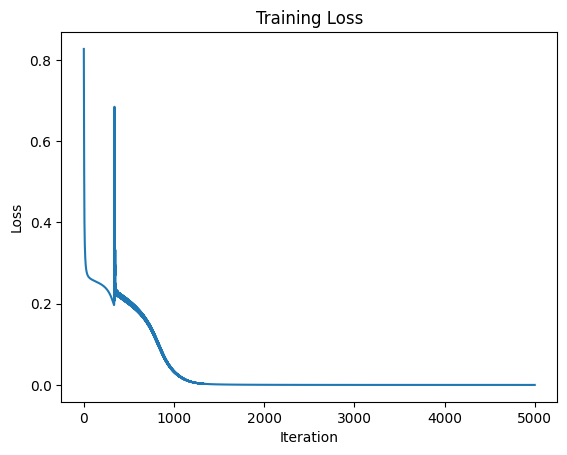

In [291]:
import torch
import torch.nn.functional as F

NUM_ATOM_TYPES = 5
NUM_BLOCKS = 1
HIDDEN_NF = 32
TANH_COORD_UPDATES = False
ATTENTION = False
AGGR_TYPE = "sum"

NUM_ITERS = 5000
LR = 0.05

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.to(device)
print(f"Center of mass of real molecule positions: {real_pos.mean(dim=0)}")
print(f"Std of real molecule positions: {real_pos.std(dim=0)}")

real_types = real_mol.real_atom_types
real_types = real_types.to(device)
print(f"Real molecule atom types shape: {real_types.shape}")
real_mol_combined = torch.cat([real_pos, real_types], dim=1)
print(f"Combined real molecule shape: {real_mol_combined.shape}")

# Sample noise once with the same shape
# as the real molecules
pos_noise = torch.randn_like(real_mol.pos, device=device)
pos_noise = pos_noise - pos_noise.mean(dim=0)
pos_noise = pos_noise / pos_noise.std(dim=0)
dense_edge_index = real_mol.dense_edge_index
dense_edge_index = dense_edge_index.to(device)
type_noise = torch.randn((real_mol.num_nodes, NUM_ATOM_TYPES), device=device)
combined_noise = torch.cat([pos_noise, type_noise], dim=1)
print(f"Combined noise shape: {combined_noise.shape}")
print()

# Instantiate model and optimizer
model = EGNN(
    num_atom_types=NUM_ATOM_TYPES,
    num_blocks=NUM_BLOCKS,
    hidden_nf=HIDDEN_NF,
    attention=ATTENTION,
    tanh_coord_updates=TANH_COORD_UPDATES,
    aggr_type=AGGR_TYPE,
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    gen_pos, gen_types = model(pos_noise, type_noise, dense_edge_index)
    gen_pos = gen_pos - gen_pos.mean(dim=0)
    gen_mol_combined = torch.cat([gen_pos, gen_types], dim=1)
    V = real_mol_combined - gen_mol_combined
    gen_mol_drifted = (gen_mol_combined + V).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol_combined)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)

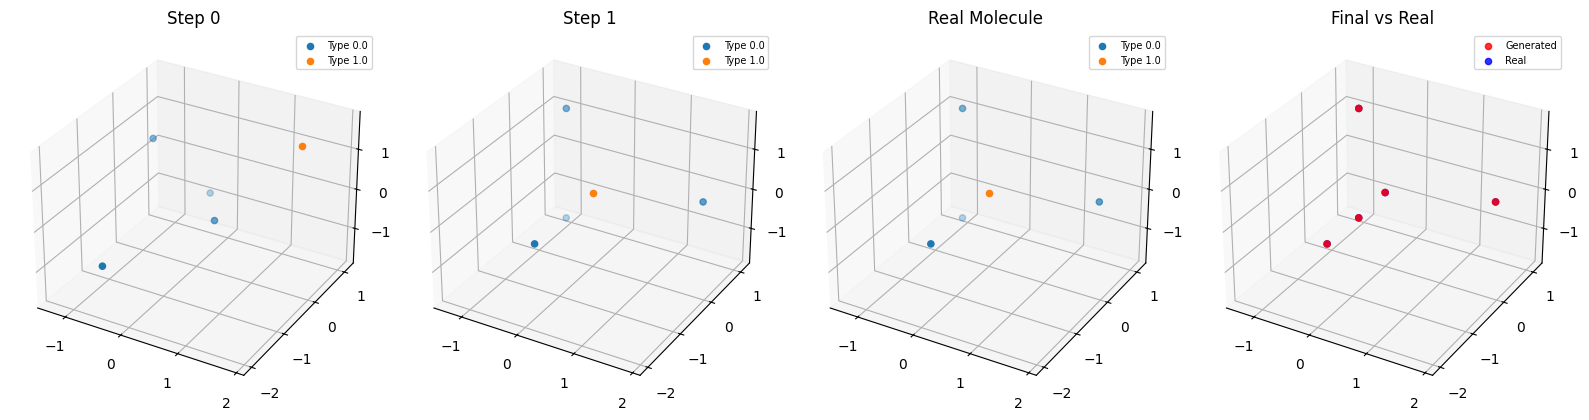

In [ ]:
gen_pos, gen_types, pos_list = model(
    pos_noise, type_noise, dense_edge_index, return_change_in_pos=True
)
gen_pos = gen_pos - gen_pos.mean(dim=0)

print(f"Generated atom types (rounded): \n {gen_types.round()}")

# Center pos_list
pos_list = [p - p.mean(dim=0) for p in pos_list]

gen_types_argmax = gen_types.argmax(dim=1).float()
real_types_argmax = real_types.argmax(dim=1).float()

# pos_list is e.g. the trajectory saved during your diffusion reverse process
visualize_progression_with_real(
    pos_list=pos_list,
    gen_types=gen_types_argmax,
    real_pos=real_pos,
    real_types=real_types_argmax,
    max_steps=len(pos_list)        # shows 6 evenly-spaced snapshots + real on the right
)

# Sample Multiple Noise ONCE

- Increasing hidden dimension is more effective than increasing depth when generating multiple molecules

Number of nodes: 5
Iter 99: Loss = 0.30308544635772705
Iter 199: Loss = 0.28667956590652466
Iter 299: Loss = 0.27179446816444397
Iter 399: Loss = 0.25089842081069946
Iter 499: Loss = 0.24536453187465668
Iter 599: Loss = 0.2160639464855194
Iter 699: Loss = 0.19182159006595612
Iter 799: Loss = 0.16807861626148224
Iter 899: Loss = 0.14635013043880463
Iter 999: Loss = 0.20844575762748718
Iter 1099: Loss = 0.08826205879449844
Iter 1199: Loss = 0.06892230361700058
Iter 1299: Loss = 0.05531327426433563
Iter 1399: Loss = 0.04445075988769531
Iter 1499: Loss = 0.037782277911901474
Iter 1599: Loss = 0.039174556732177734
Iter 1699: Loss = 0.025772741064429283
Iter 1799: Loss = 0.020792126655578613
Iter 1899: Loss = 0.0176077987998724
Iter 1999: Loss = 0.014248207211494446
Iter 2099: Loss = 0.013491068035364151
Iter 2199: Loss = 0.011059665121138096
Iter 2299: Loss = 0.009733183309435844
Iter 2399: Loss = 0.008252224884927273
Iter 2499: Loss = 0.007521637715399265
Iter 2599: Loss = 0.00711450865492

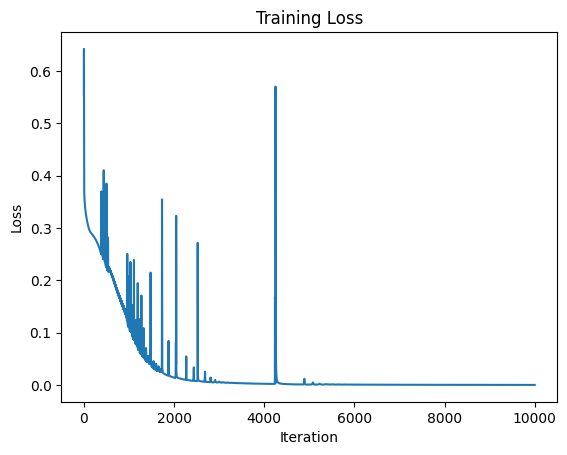

In [302]:

import torch
import torch.nn.functional as F

N_GEN_MOLS = 10

NUM_ATOM_TYPES = 5
NUM_BLOCKS = 1
HIDDEN_NF = 64
TANH_COORD_UPDATES = False
ATTENTION = False
AGGR_TYPE = "sum"

NUM_ITERS = 10000
LR = 0.05

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.to(device)

real_types = real_mol.real_atom_types
real_types = real_types.to(device)

real_mol_combined = torch.cat([real_pos, real_types], dim=1)

real_types_flattened = real_types.view(1, -1)
real_pos_flattened = real_pos.view(1, -1)

# Instantiate model and optimizer
model = EGNN(
    num_atom_types=NUM_ATOM_TYPES,
    num_blocks=NUM_BLOCKS,
    hidden_nf=HIDDEN_NF,
    attention=ATTENTION,
    tanh_coord_updates=TANH_COORD_UPDATES,
    aggr_type=AGGR_TYPE,
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

# Sample noise once with the same shape
# as the real molecules
batch_vec = torch.arange(N_GEN_MOLS, device=device).repeat_interleave(real_mol.num_nodes)
pos_noise = torch.randn((N_GEN_MOLS * real_mol.num_nodes, 3), device=device)
pos_noise = center_positions_per_mol(pos_noise, batch_vec)
pos_noise = pos_noise / pos_noise.std(dim=0)
type_noise = torch.randn((N_GEN_MOLS * real_mol.num_nodes, NUM_ATOM_TYPES), device=device)

dense_edge_index = real_mol.dense_edge_index
edge_index_list = []
for offset in range(N_GEN_MOLS):
    offset_edge_index = dense_edge_index + offset * real_mol.num_nodes
    edge_index_list.append(offset_edge_index)
dense_edge_index = torch.cat(edge_index_list, dim=1)
dense_edge_index = dense_edge_index.to(device)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    gen_pos, gen_types = model(pos_noise, type_noise, dense_edge_index)
    gen_pos = center_positions_per_mol(gen_pos, batch_vec)
    gen_mol_combined = torch.cat([gen_pos, gen_types], dim=-1)

    # Reshape to get right positions
    gen_pos = gen_pos.view(N_GEN_MOLS, -1)
    gen_types = gen_types.view(N_GEN_MOLS, -1)

    V_pos = compute_drifting_field(gen_pos, real_pos_flattened)
    V_types = compute_drifting_field(gen_types, real_types_flattened)

    V_pos = V_pos.view(N_GEN_MOLS * real_mol.num_nodes, 3)
    V_types = V_types.view(N_GEN_MOLS * real_mol.num_nodes, NUM_ATOM_TYPES)
    V_combined = torch.cat([V_pos, V_types], dim=-1)

    gen_mol_drifted = (gen_mol_combined + V_combined).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol_combined)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)

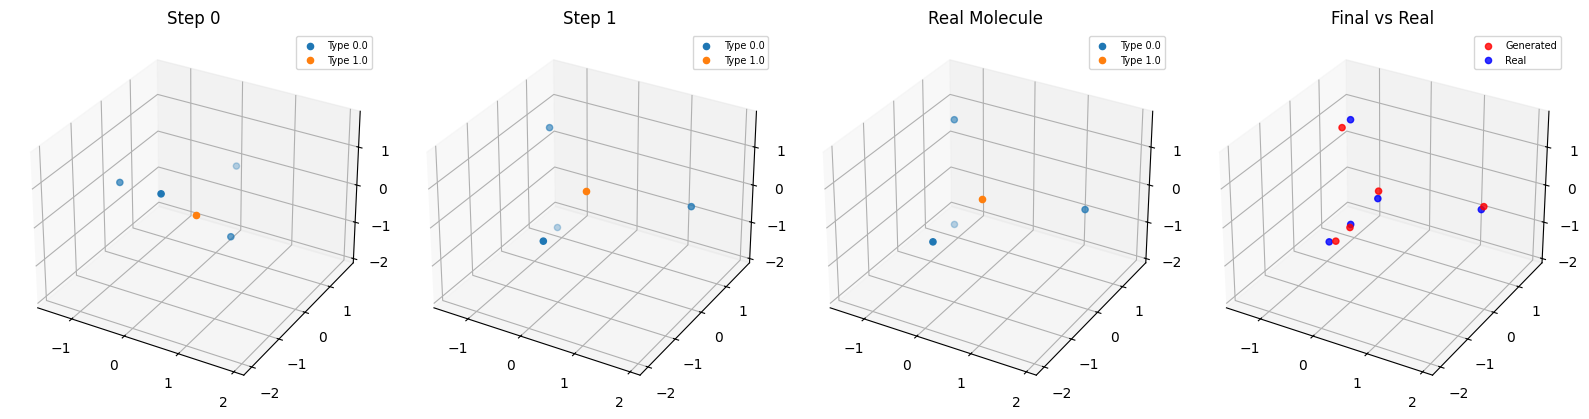

In [ ]:
gen_pos, gen_types, pos_list = model(
    pos_noise, type_noise, dense_edge_index, return_change_in_pos=True
)
gen_pos = center_positions_per_mol(gen_pos, batch_vec)

print(gen_types.round().pow(2).sum(dim=1))

gen_pos_flattened = gen_pos.view(N_GEN_MOLS, -1)
sorted_pos, closest_indices = get_sorted_mols(gen_pos_flattened, real_pos_flattened)

SELECTED_IDX = 0

selected_pos_list = []
for gen_pos_step in pos_list:
    gen_pos_step = gen_pos_step.view(N_GEN_MOLS, -1)
    ge_pos_step = gen_pos_step[SELECTED_IDX]
    gen_pos_step = ge_pos_step.view(-1, 3)
    gen_pos_step = gen_pos_step - gen_pos_step.mean(dim=0)
    selected_pos_list.append(gen_pos_step)

viz_types = gen_types.reshape(N_GEN_MOLS, -1)
viz_types = viz_types[closest_indices[SELECTED_IDX]]

viz_types = viz_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()
real_types_argmax = real_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

# pos_list is e.g. the trajectory saved during your diffusion reverse process
visualize_progression_with_real(
    pos_list=selected_pos_list,
    gen_types=viz_types,
    real_pos=real_pos,
    real_types=real_types_argmax,
    max_steps=len(selected_pos_list)
)

# Sample DIFFERENT noise every time

- Positions collapse to origin. After a conversation with Claude, we concluded that this is an impossible task for a EGNN.

An EGNN can only map noise up to a global rotation and translation, but cannot map it to a constant function (single target).

The model is translating each point after each equivariant layer. This is essentially: PosGCN(x) = x + delta. The function that minimizes the MSE with an arbitrary target is essentially the centroid of the target structure. We are centering the real positions, thus, it collapses to the origin.

The fact that the MLP was able to overfit properly is because the weights were essentially contributing 0, and the model learned the constant target withing the biases of the linear layer. This has not been verified still in the notebook, but the explanation seems sound to me.

A proper way of assessing whether EGNN is well implemented would be to align the output (or the input) with the target output. The model should be able to overfit properly.

Number of nodes: 5
Iter 99: Loss = 0.34003815054893494
Iter 199: Loss = 0.3353342115879059
Iter 299: Loss = 0.35132089257240295
Iter 399: Loss = 0.33910268545150757
Iter 499: Loss = 0.3354753851890564
Iter 599: Loss = 0.3552573323249817
Iter 699: Loss = 0.33852145075798035
Iter 799: Loss = 0.3428986668586731
Iter 899: Loss = 0.3360549211502075
Iter 999: Loss = 0.36267831921577454
Iter 1099: Loss = 0.3389829099178314
Iter 1199: Loss = 0.3298960328102112
Iter 1299: Loss = 0.34245574474334717
Iter 1399: Loss = 0.31797081232070923
Iter 1499: Loss = 0.33787134289741516
Iter 1599: Loss = 0.342614084482193
Iter 1699: Loss = 0.33675917983055115
Iter 1799: Loss = 0.3423296809196472
Iter 1899: Loss = 0.33435460925102234
Iter 1999: Loss = 0.31717512011528015
Iter 2099: Loss = 0.3471736013889313
Iter 2199: Loss = 0.33533111214637756
Iter 2299: Loss = 0.33677753806114197
Iter 2399: Loss = 0.36003759503364563
Iter 2499: Loss = 0.3321400284767151
Iter 2599: Loss = 0.3402555286884308
Iter 2699: Loss =

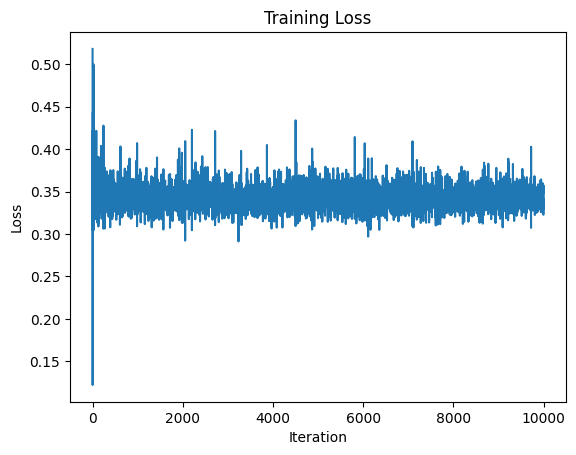

In [309]:
import torch
import torch.nn.functional as F

N_GEN_MOLS = 10

NUM_ATOM_TYPES = 5
NUM_BLOCKS = 1
HIDDEN_NF = 64
TANH_COORD_UPDATES = True
ATTENTION = True
AGGR_TYPE = "sum"

NUM_ITERS = 10000
LR = 0.05

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.to(device)

real_types = real_mol.real_atom_types
real_types = real_types.to(device)

real_mol_combined = torch.cat([real_pos, real_types], dim=1)

real_types_flattened = real_types.view(1, -1)
real_pos_flattened = real_pos.view(1, -1)

# Instantiate model and optimizer
model = EGNN(
    num_atom_types=NUM_ATOM_TYPES,
    num_blocks=NUM_BLOCKS,
    hidden_nf=HIDDEN_NF,
    attention=ATTENTION,
    tanh_coord_updates=TANH_COORD_UPDATES,
    aggr_type=AGGR_TYPE,
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

# Helpers to center noise
batch_vec = torch.arange(
    N_GEN_MOLS, device=device
).repeat_interleave(real_mol.num_nodes)

# Helper to perform forward pass
dense_edge_index = real_mol.dense_edge_index
edge_index_list = []
for offset in range(N_GEN_MOLS):
    offset_edge_index = dense_edge_index + offset * real_mol.num_nodes
    edge_index_list.append(offset_edge_index)
dense_edge_index = torch.cat(edge_index_list, dim=1)
dense_edge_index = dense_edge_index.to(device)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()

    # Sample noise at each iteration
    pos_noise = torch.randn((N_GEN_MOLS * real_mol.num_nodes, 3), device=device)
    pos_noise = center_positions_per_mol(pos_noise, batch_vec)
    pos_noise = pos_noise / pos_noise.std(dim=0)
    type_noise = torch.randn(
        (N_GEN_MOLS * real_mol.num_nodes, NUM_ATOM_TYPES),
        device=device,
    )

    gen_pos, gen_types = model(pos_noise, type_noise, dense_edge_index)
    gen_pos = center_positions_per_mol(gen_pos, batch_vec)
    gen_mol_combined = torch.cat([gen_pos, gen_types], dim=-1)

    # Reshape to get right positions
    gen_pos = gen_pos.view(N_GEN_MOLS, -1)
    gen_types = gen_types.view(N_GEN_MOLS, -1)

    V_pos = compute_drifting_field(gen_pos, real_pos_flattened)
    V_types = compute_drifting_field(gen_types, real_types_flattened)

    V_pos = V_pos.view(N_GEN_MOLS * real_mol.num_nodes, 3)
    V_types = V_types.view(N_GEN_MOLS * real_mol.num_nodes, NUM_ATOM_TYPES)
    V_combined = torch.cat([V_pos, V_types], dim=-1)

    gen_mol_drifted = (gen_mol_combined + V_combined).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol_combined)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)

In [310]:
pos_noise = torch.randn((N_GEN_MOLS * real_mol.num_nodes, 3), device=device)
pos_noise = center_positions_per_mol(pos_noise, batch_vec)
pos_noise = pos_noise / pos_noise.std(dim=0)
type_noise = torch.randn(
    (N_GEN_MOLS * real_mol.num_nodes, NUM_ATOM_TYPES),
    device=device,
)

gen_pos, gen_types, pos_list = model(
    pos_noise, type_noise, dense_edge_index, return_change_in_pos=True
)

In [311]:
gen_types.round().pow(2).sum(dim=1)

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       device='cuda:0', grad_fn=<SumBackward1>)

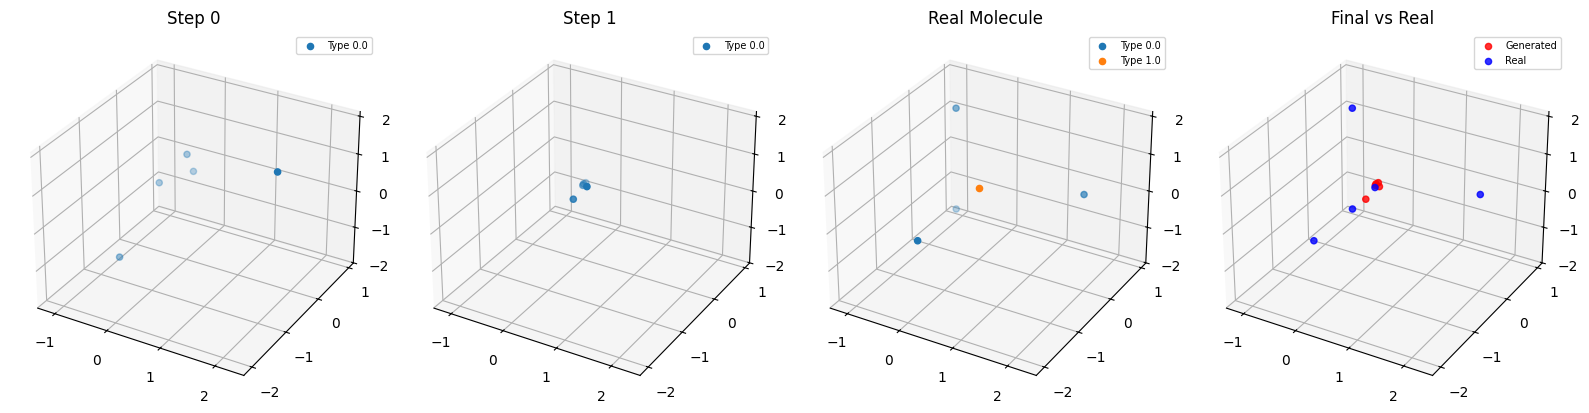

In [313]:
gen_pos_flattened = gen_pos.view(N_GEN_MOLS, -1)
sorted_pos, closest_indices = get_sorted_mols(gen_pos_flattened, real_pos_flattened)

SELECTED_IDX = 0

selected_pos_list = []
for gen_pos_step in pos_list:
    gen_pos_step = gen_pos_step.view(N_GEN_MOLS, -1)
    ge_pos_step = gen_pos_step[SELECTED_IDX]
    gen_pos_step = ge_pos_step.view(-1, 3)
    gen_pos_step = gen_pos_step - gen_pos_step.mean(dim=0)
    selected_pos_list.append(gen_pos_step)

viz_types = gen_types.reshape(N_GEN_MOLS, -1)
viz_types = viz_types[closest_indices[SELECTED_IDX]]

viz_types = viz_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()
real_types_argmax = real_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

# pos_list is e.g. the trajectory saved during your diffusion reverse process
visualize_progression_with_real(
    pos_list=selected_pos_list,
    gen_types=viz_types,
    real_pos=real_pos,
    real_types=real_types_argmax,
    max_steps=len(selected_pos_list)
)

# Kabsh Align

In [346]:

import torch
from torch_scatter import scatter_mean



def kabsch_align(P: torch.Tensor, Q: torch.Tensor) -> torch.Tensor:
    """
    Find rotation R and translation t that minimize ||R @ P.T + t - Q.T||^2,
    then return P aligned to Q.

    Args:
        P: [n_nodes, 3] source points (prediction)
        Q: [n_nodes, 3] target points

    Returns:
        P_aligned: [n_nodes, 3] - P after optimal rigid transform to match Q
    """
    # 1. Center both point clouds
    P_centroid = P.mean(dim=0, keepdim=True)  # [1, 3]
    Q_centroid = Q.mean(dim=0, keepdim=True)  # [1, 3]
    P_centered = P - P_centroid
    Q_centered = Q - Q_centroid

    # 2. Compute covariance matrix H = P_centered^T @ Q_centered
    H = P_centered.T @ Q_centered  # [3, 3]

    # 3. SVD: H = U @ S @ V^T
    U, S, Vt = torch.linalg.svd(H)

    # 4. Correct for reflection (ensure proper rotation, det = +1)
    d = torch.sign(torch.linalg.det(Vt.T @ U.T))
    D = torch.diag(torch.tensor([1.0, 1.0, d], device=P.device, dtype=P.dtype))

    # 5. Optimal rotation
    R = Vt.T @ D @ U.T  # [3, 3]

    # 6. Apply rotation and translate to Q's centroid
    P_aligned = (R @ P_centered.T).T + Q_centroid

    return P_aligned

def kabsch_align_pyg(P: torch.Tensor, Q: torch.Tensor,
                    batch: torch.Tensor, n_mols: int) -> torch.Tensor:
    """
    Vectorized Kabsch alignment for PyG-style flat layout with uniform mol size.

    Args:
        P: [N_total, 3] predictions
        Q: [N_total, 3] targets
        batch: [N_total] long tensor, molecule index per node
        n_mols: number of molecules in the batch

    Returns:
        P_aligned: [N_total, 3], each molecule rigidly aligned to its target
    """
    # 1. Per-molecule centroids and centering
    P_centroid = scatter_mean(P, batch, dim=0)  # [n_mols, 3]
    Q_centroid = scatter_mean(Q, batch, dim=0)  # [n_mols, 3]
    P_c = P - P_centroid[batch]                 # [N_total, 3]
    Q_c = Q - Q_centroid[batch]                 # [N_total, 3]

    # 2. Per-molecule covariance H_m = P_c_m^T @ Q_c_m, computed via scatter.
    # Outer product per node: [N_total, 3, 3], then sum within each molecule.
    outer = P_c.unsqueeze(2) * Q_c.unsqueeze(1)  # [N_total, 3, 3]
    H = scatter_mean(outer, batch, dim=0) * (outer.shape[0] / n_mols)
    # Note: scatter_mean gives the mean; multiplying by nodes-per-mol recovers
    # the sum. Since SVD's rotation is invariant to positive scaling of H,
    # you can actually skip this rescale — keeping it for clarity.

    # 3. Batched SVD
    U, S, Vt = torch.linalg.svd(H)  # all [n_mols, 3, 3]

    # 4. Reflection correction per molecule
    det = torch.linalg.det(Vt.transpose(-1, -2) @ U.transpose(-1, -2))  # [n_mols]
    D = torch.eye(3, device=P.device, dtype=P.dtype).expand(n_mols, -1, -1).clone()
    D[:, 2, 2] = torch.sign(det)

    R = Vt.transpose(-1, -2) @ D @ U.transpose(-1, -2)  # [n_mols, 3, 3]

    # 5. Apply rotation per node, then translate to target centroid
    R_per_node = R[batch]                                # [N_total, 3, 3]
    P_rot = torch.einsum('nij,nj->ni', R_per_node, P_c)  # [N_total, 3]
    P_aligned = P_rot + Q_centroid[batch]

    return P_aligned


def kabsch_mse_pyg(P, Q, batch, n_mols):
    P_aligned = kabsch_align_pyg(P, Q, batch, n_mols)
    return ((P_aligned - Q) ** 2).mean()

# Align output -> Single Noise

Number of nodes: 5
Center of mass of real molecule positions: tensor([0., 0., 0.], device='cuda:0')
Std of real molecule positions: tensor([1.0000, 1.0000, 1.0000], device='cuda:0')
Real molecule atom types shape: torch.Size([5, 5])
Combined real molecule shape: torch.Size([5, 8])
Combined noise shape: torch.Size([5, 8])

Iter 99: Loss = 0.10440248250961304
Iter 199: Loss = 0.03864666447043419
Iter 299: Loss = 0.028231292963027954
Iter 399: Loss = 0.018795490264892578
Iter 499: Loss = 0.011285527609288692
Iter 599: Loss = 0.007122666575014591
Iter 699: Loss = 0.005757670383900404
Iter 799: Loss = 0.0041015311144292355
Iter 899: Loss = 0.00302503420971334
Iter 999: Loss = 0.0023202765733003616
Iter 1099: Loss = 0.0018364416901022196
Iter 1199: Loss = 0.0014982852153480053
Iter 1299: Loss = 0.0012553539127111435
Iter 1399: Loss = 0.0010774299735203385
Iter 1499: Loss = 0.0009440227295272052
Iter 1599: Loss = 0.0008419441874139011
Iter 1699: Loss = 0.0007618119125254452
Iter 1799: Loss = 

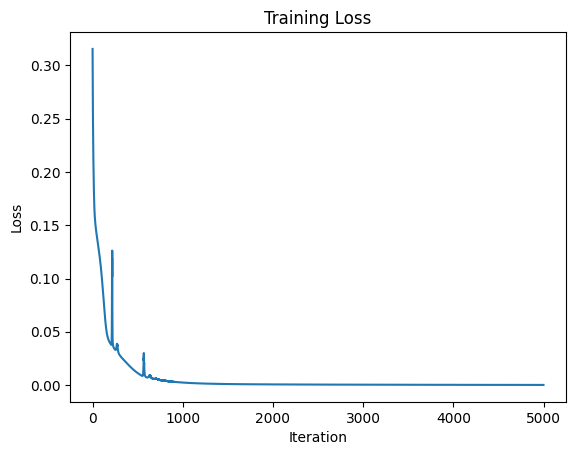

In [328]:
import torch
import torch.nn.functional as F

NUM_ATOM_TYPES = 5
NUM_BLOCKS = 1
HIDDEN_NF = 32
TANH_COORD_UPDATES = False
ATTENTION = False
AGGR_TYPE = "sum"

NUM_ITERS = 5000
LR = 0.05

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.to(device)
print(f"Center of mass of real molecule positions: {real_pos.mean(dim=0)}")
print(f"Std of real molecule positions: {real_pos.std(dim=0)}")

real_types = real_mol.real_atom_types
real_types = real_types.to(device)
print(f"Real molecule atom types shape: {real_types.shape}")
real_mol_combined = torch.cat([real_pos, real_types], dim=1)
print(f"Combined real molecule shape: {real_mol_combined.shape}")

# Sample noise once with the same shape
# as the real molecules
pos_noise = torch.randn_like(real_mol.pos, device=device)
pos_noise = pos_noise - pos_noise.mean(dim=0)
pos_noise = pos_noise / pos_noise.std(dim=0)
dense_edge_index = real_mol.dense_edge_index
dense_edge_index = dense_edge_index.to(device)
type_noise = torch.randn((real_mol.num_nodes, NUM_ATOM_TYPES), device=device)
combined_noise = torch.cat([pos_noise, type_noise], dim=1)
print(f"Combined noise shape: {combined_noise.shape}")
print()

# Instantiate model and optimizer
model = EGNN(
    num_atom_types=NUM_ATOM_TYPES,
    num_blocks=NUM_BLOCKS,
    hidden_nf=HIDDEN_NF,
    attention=ATTENTION,
    tanh_coord_updates=TANH_COORD_UPDATES,
    aggr_type=AGGR_TYPE,
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()
    gen_pos, gen_types = model(pos_noise, type_noise, dense_edge_index)
    gen_pos = gen_pos - gen_pos.mean(dim=0)
    gen_pos = kabsch_align(gen_pos, real_pos)
    gen_mol_combined = torch.cat([gen_pos, gen_types], dim=1)
    V = real_mol_combined - gen_mol_combined
    gen_mol_drifted = (gen_mol_combined + V).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol_combined)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)

Generated atom types (rounded): 
 tensor([[0., 1., 0., -0., 0.],
        [1., -0., 0., -0., -0.],
        [1., -0., -0., -0., 0.],
        [1., -0., -0., 0., 0.],
        [1., 0., -0., 0., 0.]], device='cuda:0', grad_fn=<RoundBackward0>)


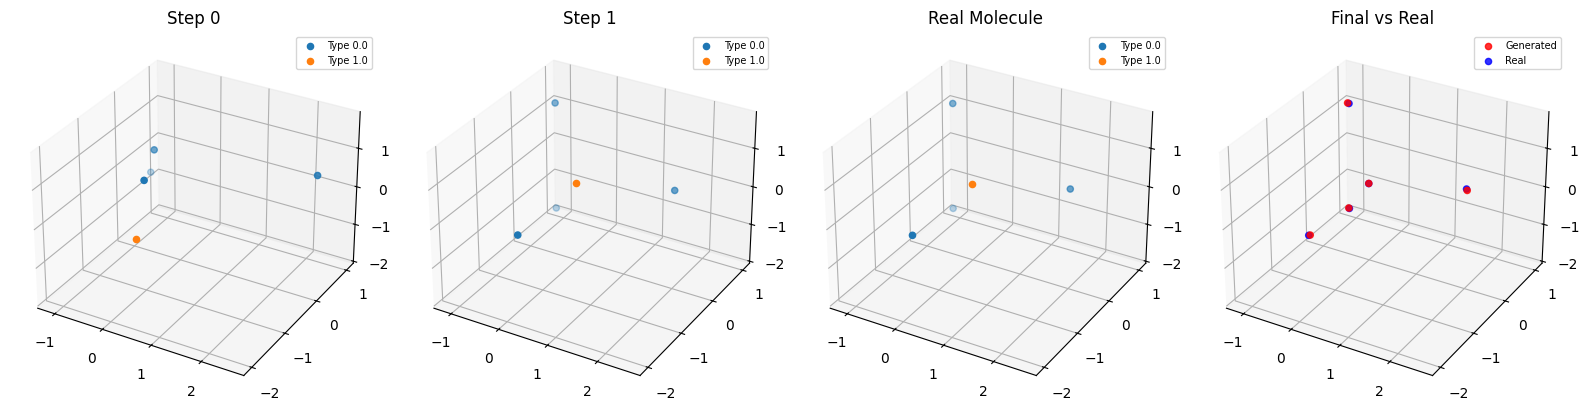

In [329]:
gen_pos, gen_types, pos_list = model(
    pos_noise, type_noise, dense_edge_index, return_change_in_pos=True
)

print(f"Generated atom types (rounded): \n {gen_types.round()}")

# Center pos_list
processed_pos_list = []
for pos_step in pos_list:
    pos_step = pos_step - pos_step.mean(dim=0)
    pos_step = kabsch_align(pos_step, real_pos)
    processed_pos_list.append(pos_step)

gen_types_argmax = gen_types.argmax(dim=1).float()
real_types_argmax = real_types.argmax(dim=1).float()

# pos_list is e.g. the trajectory saved during your diffusion reverse process
visualize_progression_with_real(
    pos_list=processed_pos_list,
    gen_types=gen_types_argmax,
    real_pos=real_pos,
    real_types=real_types_argmax,
    max_steps=len(processed_pos_list)
)

# Align -> Multiple Noise

Number of nodes: 5
Iter 99: Loss = 0.13764429092407227
Iter 199: Loss = 0.13377812504768372
Iter 299: Loss = 0.13023832440376282
Iter 399: Loss = 0.12519307434558868
Iter 499: Loss = 0.11627790331840515
Iter 599: Loss = 0.10443896055221558
Iter 699: Loss = 0.09463466703891754
Iter 799: Loss = 0.08477173000574112
Iter 899: Loss = 0.07500843703746796
Iter 999: Loss = 0.06568857282400131
Iter 1099: Loss = 0.0568385012447834
Iter 1199: Loss = 0.04908664897084236
Iter 1299: Loss = 0.04236926883459091
Iter 1399: Loss = 0.037014663219451904
Iter 1499: Loss = 0.03279367461800575
Iter 1599: Loss = 0.029323190450668335
Iter 1699: Loss = 0.026368822902441025
Iter 1799: Loss = 0.0237953569740057
Iter 1899: Loss = 0.02152765914797783
Iter 1999: Loss = 0.019520388916134834
Iter 2099: Loss = 0.01774231158196926
Iter 2199: Loss = 0.01616777293384075
Iter 2299: Loss = 0.014772433787584305
Iter 2399: Loss = 0.013532375916838646
Iter 2499: Loss = 0.012424914166331291
Iter 2599: Loss = 0.01143012009561061

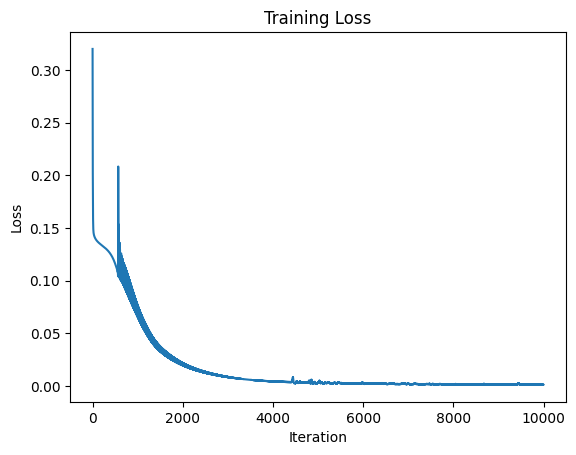

In [359]:
import torch
import torch.nn.functional as F

N_GEN_MOLS = 10

NUM_ATOM_TYPES = 5
NUM_BLOCKS = 1
HIDDEN_NF = 64
TANH_COORD_UPDATES = False
ATTENTION = False
AGGR_TYPE = "sum"

NUM_ITERS = 10000
LR = 0.05

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.to(device)

real_types = real_mol.real_atom_types
real_types = real_types.to(device)

real_mol_combined = torch.cat([real_pos, real_types], dim=1)

real_types_flattened = real_types.view(1, -1)
real_pos_flattened = real_pos.view(1, -1)

# Instantiate model and optimizer
model = EGNN(
    num_atom_types=NUM_ATOM_TYPES,
    num_blocks=NUM_BLOCKS,
    hidden_nf=HIDDEN_NF,
    attention=ATTENTION,
    tanh_coord_updates=TANH_COORD_UPDATES,
    aggr_type=AGGR_TYPE,
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

# Sample noise once with the same shape
# as the real molecules
batch_vec = torch.arange(N_GEN_MOLS, device=device).repeat_interleave(real_mol.num_nodes)
pos_noise = torch.randn((N_GEN_MOLS * real_mol.num_nodes, 3), device=device)
pos_noise = center_positions_per_mol(pos_noise, batch_vec)
pos_noise = pos_noise / pos_noise.std(dim=0)
type_noise = torch.randn((N_GEN_MOLS * real_mol.num_nodes, NUM_ATOM_TYPES), device=device)

dense_edge_index = real_mol.dense_edge_index
edge_index_list = []
for offset in range(N_GEN_MOLS):
    offset_edge_index = dense_edge_index + offset * real_mol.num_nodes
    edge_index_list.append(offset_edge_index)
dense_edge_index = torch.cat(edge_index_list, dim=1)
dense_edge_index = dense_edge_index.to(device)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()

    gen_pos, gen_types = model(pos_noise, type_noise, dense_edge_index)
    gen_pos = center_positions_per_mol(gen_pos, batch_vec)

    gen_pos = kabsch_align_pyg(
        gen_pos,
        real_pos.repeat(N_GEN_MOLS, 1),
        batch_vec,
        N_GEN_MOLS,
    )
    gen_mol_combined = torch.cat([gen_pos, gen_types], dim=-1)

    # Reshape to get right positions
    gen_pos = gen_pos.view(N_GEN_MOLS, -1)
    gen_types = gen_types.view(N_GEN_MOLS, -1)

    V_pos = compute_drifting_field(gen_pos, real_pos_flattened)
    V_types = compute_drifting_field(gen_types, real_types_flattened)

    V_pos = V_pos.view(N_GEN_MOLS * real_mol.num_nodes, 3)
    V_types = V_types.view(N_GEN_MOLS * real_mol.num_nodes, NUM_ATOM_TYPES)
    V_combined = torch.cat([V_pos, V_types], dim=-1)

    gen_mol_drifted = (gen_mol_combined + V_combined).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol_combined)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       device='cuda:0', grad_fn=<SumBackward1>)


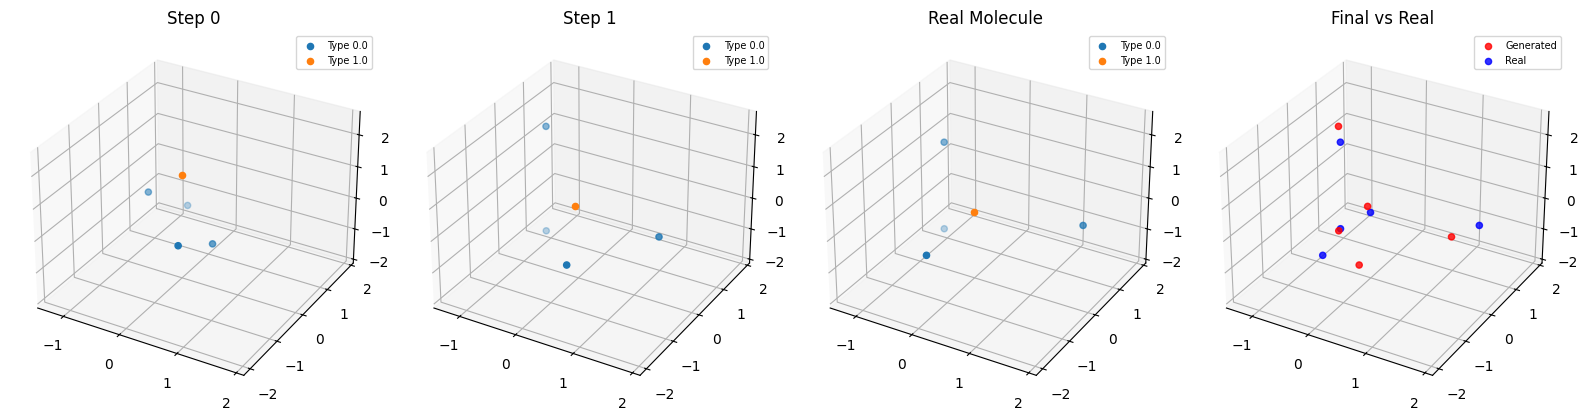

In [361]:
gen_pos, gen_types, pos_list = model(
    pos_noise, type_noise, dense_edge_index, return_change_in_pos=True
)
gen_pos = center_positions_per_mol(gen_pos, batch_vec)
gen_pos = kabsch_align_pyg(
    gen_pos,
    real_pos.repeat(N_GEN_MOLS, 1),
    batch_vec,
    N_GEN_MOLS,
)

print(gen_types.round().pow(2).sum(dim=1))

gen_pos_flattened = gen_pos.view(N_GEN_MOLS, -1)
sorted_pos, closest_indices = get_sorted_mols(gen_pos_flattened, real_pos_flattened)

SELECTED_IDX = 0

selected_pos_list = []
for gen_pos_step in pos_list:
    gen_pos_step = gen_pos_step.view(N_GEN_MOLS, -1)
    ge_pos_step = gen_pos_step[SELECTED_IDX]
    gen_pos_step = ge_pos_step.view(-1, 3)
    gen_pos_step = gen_pos_step - gen_pos_step.mean(dim=0)
    gen_pos_step = kabsch_align(gen_pos_step, real_pos)
    selected_pos_list.append(gen_pos_step)

viz_types = gen_types.reshape(N_GEN_MOLS, -1)
viz_types = viz_types[closest_indices[SELECTED_IDX]]

viz_types = viz_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()
real_types_argmax = real_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

# pos_list is e.g. the trajectory saved during your diffusion reverse process
visualize_progression_with_real(
    pos_list=selected_pos_list,
    gen_types=viz_types,
    real_pos=real_pos,
    real_types=real_types_argmax,
    max_steps=len(selected_pos_list)
)

# Align -> Arbitrary Noise

Number of nodes: 5
Iter 99: Loss = 0.15006884932518005
Iter 199: Loss = 0.19007663428783417
Iter 299: Loss = 0.16954493522644043
Iter 399: Loss = 0.1854722499847412
Iter 499: Loss = 0.16074953973293304
Iter 599: Loss = 0.1789349764585495
Iter 699: Loss = 0.16859504580497742
Iter 799: Loss = 0.1812606155872345
Iter 899: Loss = 0.17191368341445923
Iter 999: Loss = 0.16284342110157013
Iter 1099: Loss = 0.16394904255867004
Iter 1199: Loss = 0.1522589474916458
Iter 1299: Loss = 0.17476321756839752
Iter 1399: Loss = 0.1509718894958496
Iter 1499: Loss = 0.18688270449638367
Iter 1599: Loss = 0.17654013633728027
Iter 1699: Loss = 0.153657466173172
Iter 1799: Loss = 0.20123441517353058
Iter 1899: Loss = 0.17906196415424347
Iter 1999: Loss = 0.14252981543540955
Iter 2099: Loss = 0.19554556906223297
Iter 2199: Loss = 0.15858528017997742
Iter 2299: Loss = 0.18907910585403442
Iter 2399: Loss = 0.14466053247451782
Iter 2499: Loss = 0.16078083217144012
Iter 2599: Loss = 0.16376712918281555
Iter 2699: 

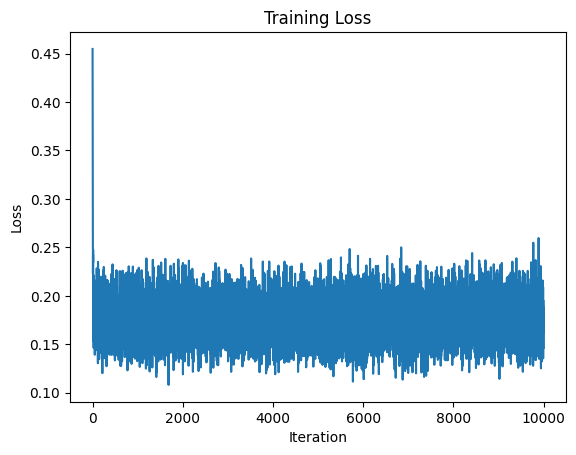

In [357]:
import torch
import torch.nn.functional as F

N_GEN_MOLS = 10

NUM_ATOM_TYPES = 5
NUM_BLOCKS = 1
HIDDEN_NF = 64
TANH_COORD_UPDATES = False
ATTENTION = False
AGGR_TYPE = "sum"

NUM_ITERS = 10000
LR = 0.05

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

real_mol = dataset[0]
print(f"Number of nodes: {real_mol.num_nodes}")
real_pos = real_mol.pos
# Zero center the real molecule positions
real_pos = real_pos - real_pos.mean(dim=0)
real_pos = real_pos / real_pos.std(dim=0)
real_pos = real_pos.to(device)

real_types = real_mol.real_atom_types
real_types = real_types.to(device)

real_mol_combined = torch.cat([real_pos, real_types], dim=1)

real_types_flattened = real_types.view(1, -1)
real_pos_flattened = real_pos.view(1, -1)

# Instantiate model and optimizer
model = EGNN(
    num_atom_types=NUM_ATOM_TYPES,
    num_blocks=NUM_BLOCKS,
    hidden_nf=HIDDEN_NF,
    attention=ATTENTION,
    tanh_coord_updates=TANH_COORD_UPDATES,
    aggr_type=AGGR_TYPE,
)
model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

# Sample noise once with the same shape
# as the real molecules
batch_vec = torch.arange(N_GEN_MOLS, device=device).repeat_interleave(real_mol.num_nodes)

dense_edge_index = real_mol.dense_edge_index
edge_index_list = []
for offset in range(N_GEN_MOLS):
    offset_edge_index = dense_edge_index + offset * real_mol.num_nodes
    edge_index_list.append(offset_edge_index)
dense_edge_index = torch.cat(edge_index_list, dim=1)
dense_edge_index = dense_edge_index.to(device)

loss_list = []
for iter in range(NUM_ITERS):
    optimizer.zero_grad()

    pos_noise = torch.randn((N_GEN_MOLS * real_mol.num_nodes, 3), device=device)
    pos_noise = center_positions_per_mol(pos_noise, batch_vec)
    pos_noise = pos_noise / pos_noise.std(dim=0)
    type_noise = torch.randn((N_GEN_MOLS * real_mol.num_nodes, NUM_ATOM_TYPES), device=device)

    gen_pos, gen_types = model(pos_noise, type_noise, dense_edge_index)
    gen_pos = center_positions_per_mol(gen_pos, batch_vec)
    gen_pos = kabsch_align_pyg(
        gen_pos,
        real_pos.repeat(N_GEN_MOLS, 1),
        batch_vec,
        N_GEN_MOLS,
    )
    gen_mol_combined = torch.cat([gen_pos, gen_types], dim=-1)

    # Reshape to get right positions
    gen_pos = gen_pos.view(N_GEN_MOLS, -1)
    gen_types = gen_types.view(N_GEN_MOLS, -1)

    V_pos = compute_drifting_field(gen_pos, real_pos_flattened)
    V_types = compute_drifting_field(gen_types, real_types_flattened)

    V_pos = V_pos.view(N_GEN_MOLS * real_mol.num_nodes, 3)
    V_types = V_types.view(N_GEN_MOLS * real_mol.num_nodes, NUM_ATOM_TYPES)
    V_combined = torch.cat([V_pos, V_types], dim=-1)

    gen_mol_drifted = (gen_mol_combined + V_combined).detach()
    loss = F.mse_loss(gen_mol_drifted, gen_mol_combined)
    loss.backward()
    optimizer.step()
    loss_list.append(loss.mean().item())
    if (iter + 1) % 100 == 0:
        print(f"Iter {iter}: Loss = {loss.mean().item()}")

plot_loss(loss_list)

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       device='cuda:0', grad_fn=<SumBackward1>)


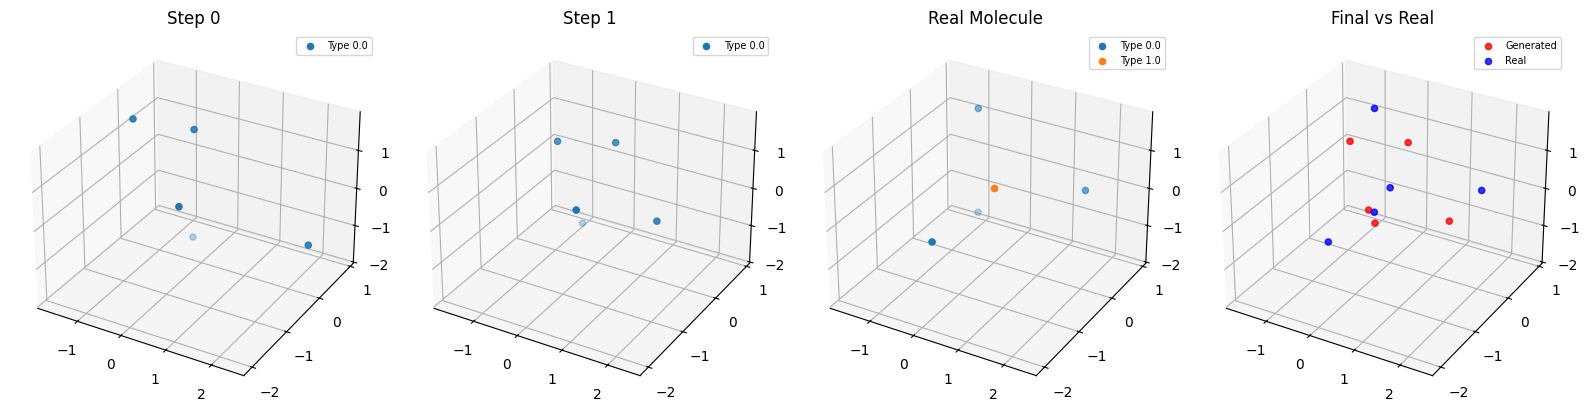

In [358]:
pos_noise = torch.randn((N_GEN_MOLS * real_mol.num_nodes, 3), device=device)
pos_noise = center_positions_per_mol(pos_noise, batch_vec)
pos_noise = pos_noise / pos_noise.std(dim=0)
type_noise = torch.randn((N_GEN_MOLS * real_mol.num_nodes, NUM_ATOM_TYPES), device=device)

gen_pos, gen_types, pos_list = model(
    pos_noise, type_noise, dense_edge_index, return_change_in_pos=True
)
gen_pos = center_positions_per_mol(gen_pos, batch_vec)
gen_pos = kabsch_align_pyg(
            gen_pos,
            real_pos.repeat(N_GEN_MOLS, 1),
            batch_vec,
            N_GEN_MOLS,
        )

print(gen_types.round().pow(2).sum(dim=1))

gen_pos_flattened = gen_pos.view(N_GEN_MOLS, -1)
sorted_pos, closest_indices = get_sorted_mols(gen_pos_flattened, real_pos_flattened)

SELECTED_IDX = 9

selected_pos_list = []
for gen_pos_step in pos_list:
    gen_pos_step = gen_pos_step.view(N_GEN_MOLS, -1)
    ge_pos_step = gen_pos_step[SELECTED_IDX]
    gen_pos_step = ge_pos_step.view(-1, 3)
    gen_pos_step = gen_pos_step - gen_pos_step.mean(dim=0)
    gen_pos_step = kabsch_align(gen_pos_step, real_pos)
    selected_pos_list.append(gen_pos_step)

viz_types = gen_types.reshape(N_GEN_MOLS, -1)
viz_types = viz_types[closest_indices[SELECTED_IDX]]

viz_types = viz_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()
real_types_argmax = real_types.view(-1, NUM_ATOM_TYPES).argmax(dim=1).float()

# pos_list is e.g. the trajectory saved during your diffusion reverse process
visualize_progression_with_real(
    pos_list=selected_pos_list,
    gen_types=viz_types,
    real_pos=real_pos,
    real_types=real_types_argmax,
    max_steps=len(selected_pos_list)
)